<a href="https://colab.research.google.com/github/azizdaim/epl-data-analysis/blob/main/epl_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Premier League EDA
Exploring 25 seasons (2000/01–2024/25) of match data to answer
a few questions I'm curious about as an EPL fan, starting with
home advantage.

## Setup
Loading the data and converting MatchDate to a proper datetime type.

In [1]:
import pandas as pd

df = pd.read_csv('epl_final.csv')
df['MatchDate'] = pd.to_datetime(df['MatchDate'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Season             9380 non-null   object        
 1   MatchDate          9380 non-null   datetime64[ns]
 2   HomeTeam           9380 non-null   object        
 3   AwayTeam           9380 non-null   object        
 4   FullTimeHomeGoals  9380 non-null   int64         
 5   FullTimeAwayGoals  9380 non-null   int64         
 6   FullTimeResult     9380 non-null   object        
 7   HalfTimeHomeGoals  9380 non-null   int64         
 8   HalfTimeAwayGoals  9380 non-null   int64         
 9   HalfTimeResult     9380 non-null   object        
 10  HomeShots          9380 non-null   int64         
 11  AwayShots          9380 non-null   int64         
 12  HomeShotsOnTarget  9380 non-null   int64         
 13  AwayShotsOnTarget  9380 non-null   int64         
 14  HomeCorn

## Question 1: Is home advantage real in this data?

In [2]:
df['FullTimeResult'].value_counts()

,count
FullTimeResult,
H,4299
A,2768
D,2313


In [3]:
df['FullTimeResult'].value_counts(normalize=True)

,proportion
FullTimeResult,
H,0.458316
A,0.295096
D,0.246588


In [4]:
df.groupby('Season')['FullTimeResult'].value_counts(normalize=True)

Season   FullTimeResult
2000/01  H                 0.484211
         D                 0.265789
         A                 0.250000
2001/02  H                 0.434211
         A                 0.300000
                             ...   
2023/24  A                 0.323684
         D                 0.215789
2024/25  H                 0.411429
         A                 0.337143
         D                 0.251429
Name: proportion, Length: 75, dtype: float64

**Finding:** Home teams win 45.8% of matches vs. 29.5% for away teams
— a clear home advantage. But breaking it down by season shows this
isn't constant: home win rate dropped from ~48% in 2000/01 to ~41%
in 2024/25, while away win rate climbed from 25% to ~34%. Home
advantage has been shrinking over time.

## Question 2: Which teams are strongest at home?
Creating a HomeWin column (1 if the home team won, 0 otherwise) so
I can average it per team to get each team's home win rate.

In [5]:
df['HomeWin'] = (df['FullTimeResult'] == 'H').astype(int)

home_win_rate = df.groupby('HomeTeam')['HomeWin'].mean().sort_values(ascending=False)
home_win_rate.head(10)

,HomeWin
HomeTeam,
Man United,0.678038
Arsenal,0.670940
Liverpool,0.657388
Man City,0.651111
Chelsea,0.637527
Tottenham,0.586354
Newcastle,0.474419
Everton,0.473461
Stoke,0.426316


Before trusting these numbers, checking how many home games each
team has actually played — teams in the league longer will
naturally have more games, which could be skewing the ranking.

In [6]:
games_played = df.groupby('HomeTeam')['HomeWin'].count().sort_values()
games_played.head(10)

,HomeWin
HomeTeam,
Bradford,19
Blackpool,19
Coventry,19
Luton,19
Huddersfield,38
Cardiff,38
Ipswich,55
Nott'm Forest,55
Derby,57


Filtering to teams with at least 300 home games (~15+ seasons in
the league) so the win rate reflects real ability, not small-sample luck.

In [7]:
qualified_teams = games_played[games_played >= 300].index
filtered_win_rate = home_win_rate[home_win_rate.index.isin(qualified_teams)]
filtered_win_rate

,HomeWin
HomeTeam,
Man United,0.678038
Arsenal,0.670940
Liverpool,0.657388
Man City,0.651111
Chelsea,0.637527
Tottenham,0.586354
Newcastle,0.474419
Everton,0.473461
Fulham,0.423881


## Visualizing the home advantage trend
Plotting home win rate by season to see the decline visually.

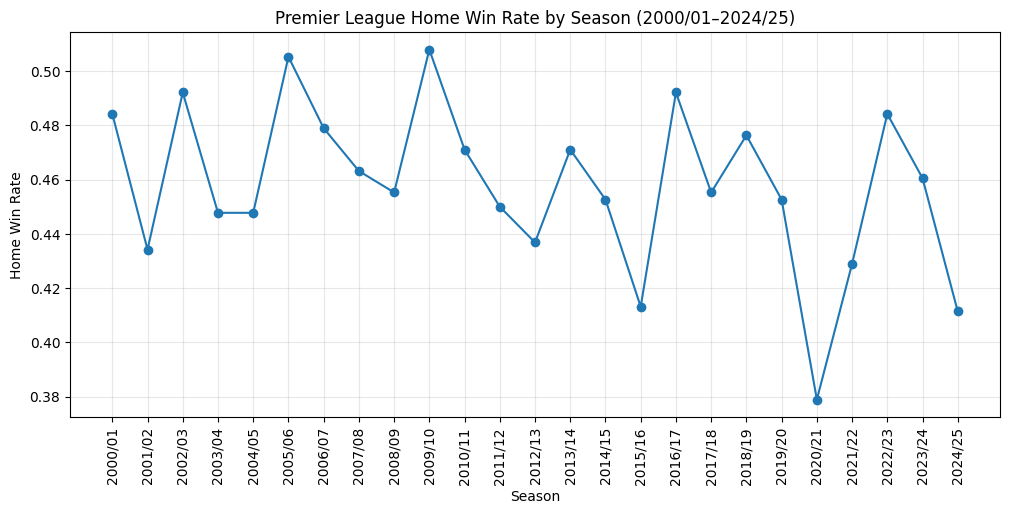

In [8]:
import matplotlib.pyplot as plt

season_home_rate = df.groupby('Season')['HomeWin'].mean()

plt.figure(figsize=(12, 5))
plt.plot(season_home_rate.index, season_home_rate.values, marker='o')
plt.xticks(rotation=90)
plt.title('Premier League Home Win Rate by Season (2000/01–2024/25)')
plt.xlabel('Season')
plt.ylabel('Home Win Rate')
plt.grid(True, alpha=0.3)
plt.show()